In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Set index col name to job_index
df.index.name = 'job_index'

In [15]:
# Creating the pivot table after adding job_posted_month_name as a column
df_data_analyst = df[df['job_title_short']=='Data Analyst'].copy()
df_data_analyst['job_posted_month_name'] = df_data_analyst['job_posted_date'].dt.strftime('%b')

# Create the List of all Month names directly from this table --> Not in order but order doesn't needed as these are direct keys going to be mapped to the direct values iin the dictionary
month_names = df_data_analyst['job_posted_month_name'].unique()

data_analyst_dict = {month: df_data_analyst[df_data_analyst['job_posted_month_name']==month] for month in month_names}

data_analyst_dict


{'Jan':           job_title_short                                          job_title  \
 job_index                                                                      
 1            Data Analyst                                       Data Analyst   
 142          Data Analyst                               Data Analyst (m/f/d)   
 155          Data Analyst                                       Data Analyst   
 170          Data Analyst    Projects & Solutions Data Analyst (UK Pensions)   
 171          Data Analyst  Data Base work from home job/internship at Mga...   
 ...                   ...                                                ...   
 785628       Data Analyst                                       Data Analyst   
 785633       Data Analyst        Data Analyst Senior - Full-time / Part-time   
 785691       Data Analyst                     Business Intelligence Engineer   
 785703       Data Analyst            Data Analyst - CRYPTOGRAPHY - Full-time   
 785705       Data An

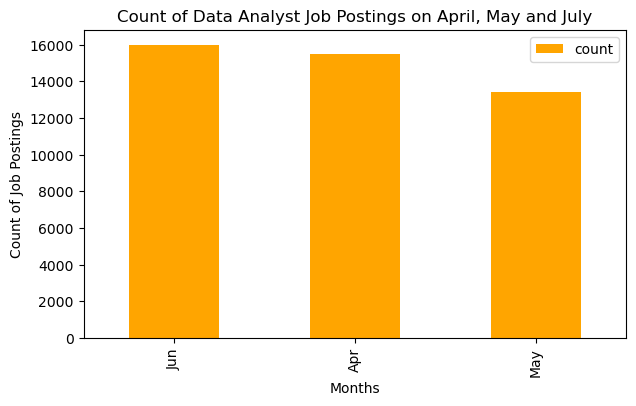

In [32]:
# Concat data from Mid-Quarter --> April, May, June
mid_quarter_data_analyst_data = pd.concat([data_analyst_dict['Apr'], data_analyst_dict['May'], data_analyst_dict['Jun']])

# 1. What value_counts() actually does
# Think of value_counts() as a "frequency counter." When you run it on the 'job_posted_month_name' column, it performs three steps automatically:
# Grouping: It looks at every unique string in that column ("April", "May", "June").
# Counting: It counts how many times each string appears.
# Sorting: It automatically sorts the results from the highest count to the lowest.
row_count_for_months = mid_quarter_data_analyst_data['job_posted_month_name'].value_counts()

row_count_for_months.plot(kind = 'bar', width = 0.5, color = 'orange', figsize=(7, 4))
plt.title("Count of Data Analyst Job Postings on April, May and July")
plt.xlabel("Months")
plt.ylabel("Count of Job Postings")
plt.legend()
plt.show()

### 🟨 Concat Job Types (2.8.3)

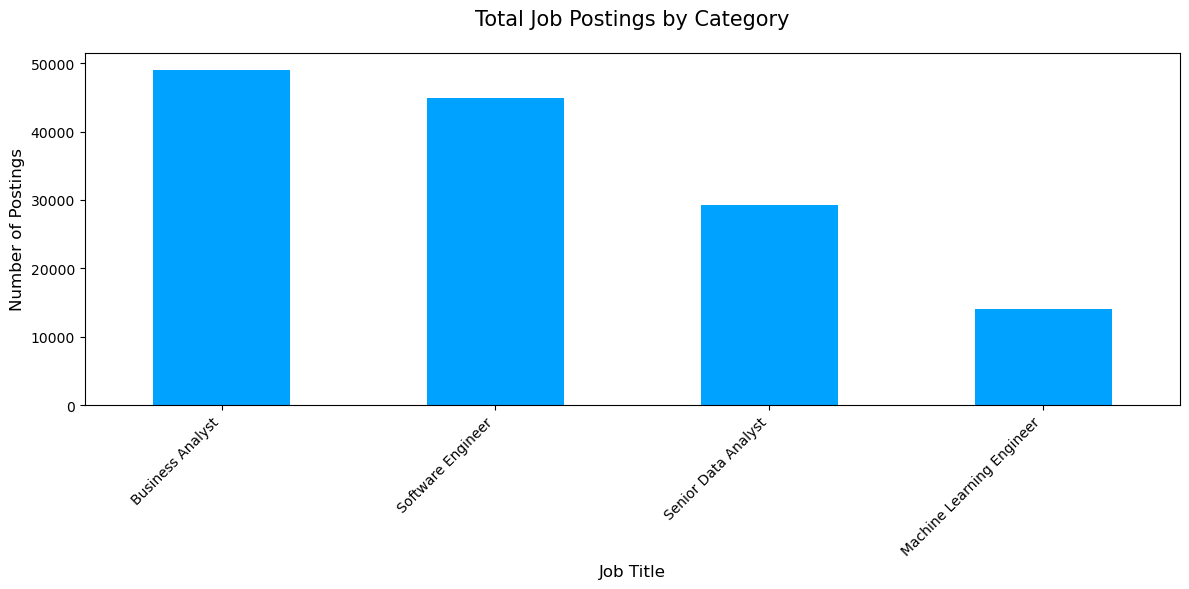

In [ ]:
df_copy = df.copy()

# Getting the List of all Job Titles
job_title_list = df_copy['job_title_short'].unique()
job_title_list

# Creating the job title dict
job_title_dict = {job_title: df_copy[df_copy['job_title_short']==job_title] for job_title in job_title_list}

# Creating the concated data for Software Engineer, Machine Learning Engineer and Business Analyst
concatted_data = pd.concat([job_title_dict['Machine Learning Engineer'], job_title_dict['Software Engineer'], job_title_dict['Business Analyst'], job_title_dict['Senior Data Analyst']])

final_data_with_titles = concatted_data['job_title_short'].value_counts()

# 1. Create the plot
ax = final_data_with_titles.plot(kind='bar', figsize=(12, 6), color='#00a2ff')

# 2. Set the Title and Axis Labels
plt.title('Total Job Postings by Category', fontsize=15, pad=20)
plt.xlabel('Job Title', fontsize=12)
plt.ylabel('Number of Postings', fontsize=12)

# 3. Set Index Labels and Rotation
# 'rotation=45' is standard, 'ha=right' aligns the text end to the tick mark
plt.xticks(rotation=45, ha='right')

# 4. Final layout adjustment to prevent labels from being cut off
plt.tight_layout()
plt.show()
